In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
import joblib

In [2]:
import sys
print(sys.executable)


/Users/aashshah/Documents/coding/.venv/bin/python


In [5]:

#setting plot style 
plt.style.use("default")

#oad the data 
data_path = "../data/survey_lung_cancer.csv"  # adjust if needed
df = pd.read_csv(data_path)

df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [7]:
#eda shape and statistics
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())

print("\nSummary statistics:")
display(df.describe(include="all"))

Shape: (309, 16)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15 

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
count,309,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YES
freq,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,270
mean,NaN,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634,NaN
std,NaN,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588,NaN
min,NaN,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN
25%,NaN,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN
50%,NaN,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,NaN
75%,NaN,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,NaN


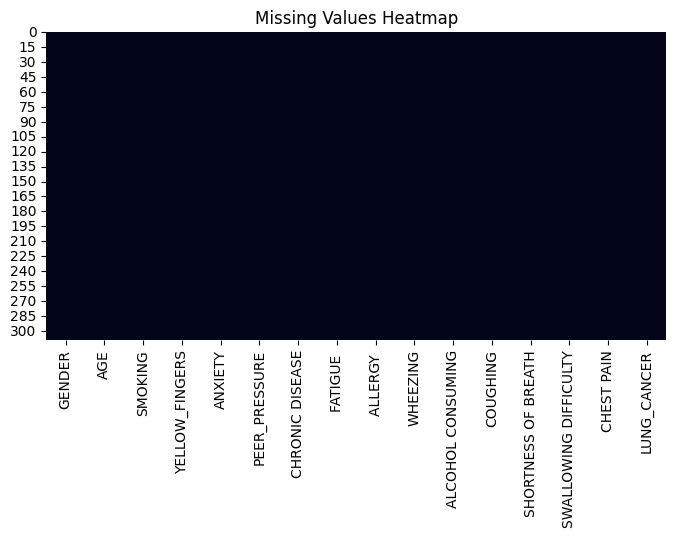

In [8]:
#heatmap of missing values
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

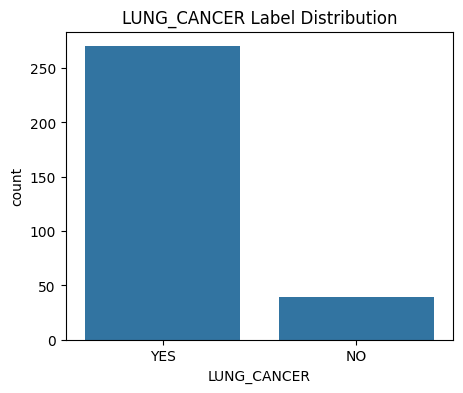

In [9]:
#target distribution (assuming column name is 'LUNG_CANCER')
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='LUNG_CANCER')
plt.title("LUNG_CANCER Label Distribution")
plt.show()

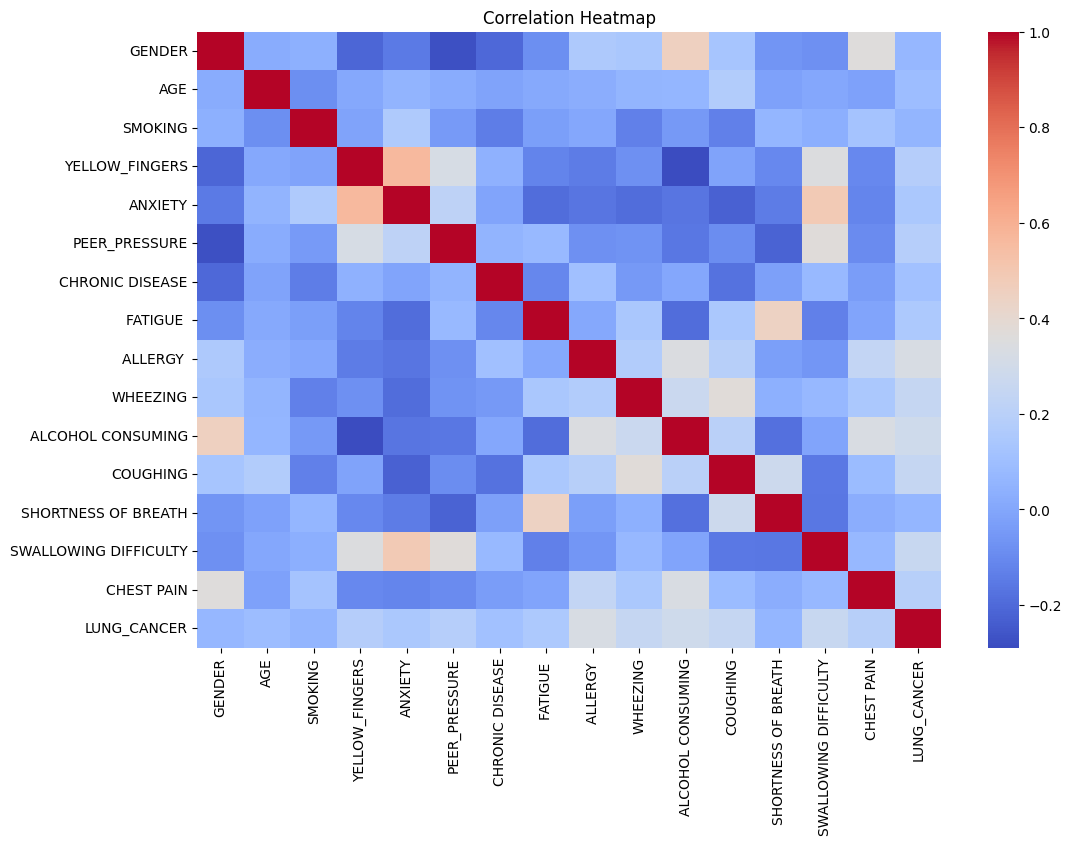

In [20]:
#correlation heatmap we also convert the yes no to numeric data 
df_corr = df.copy()
for col in df_corr.columns:
    if df_corr[col].dtype == 'object':
        df_corr[col] = df_corr[col].astype('category').cat.codes

#display data graphically
plt.figure(figsize=(12, 8))
sns.heatmap(df_corr.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [12]:
#preprocessing the data by encoding the data 
df_proc = df.copy()
label_encoders = {}
for col in df_proc.columns:
    if df_proc[col].dtype == 'object':
        le = LabelEncoder()
        df_proc[col] = le.fit_transform(df_proc[col])
        label_encoders[col] = le

In [15]:
#split the data by seperating the features and target 
x = df_proc.drop('LUNG_CANCER', axis=1)
y = df_proc['LUNG_CANCER']

#training and testing the split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
    )

In [16]:
#scaling the features 
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

x_train_scaled.shape, x_test_scaled.shape

((247, 15), (62, 15))

In [18]:
#model benchmarking

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42
    )
}

results = []

for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df.sort_values("Accuracy", ascending=False)


,Model,Accuracy
4,Decision Tree,0.919355
5,Random Forest,0.919355
0,Logistic Regression,0.903226
6,XGBoost,0.887097
2,KNN,0.870968
1,SVM,0.854839
3,Naive Bayes,0.854839


In [22]:
#training the best model 
best_model = RandomForestClassifier(random_state=42)
best_model.fit(x_train_scaled, y_train)
y_pred = best_model.predict(x_test_scaled)

Accuracy: 91.94%

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.75      0.71         8
           1       0.96      0.94      0.95        54

    accuracy                           0.92        62
   macro avg       0.81      0.85      0.83        62
weighted avg       0.92      0.92      0.92        62



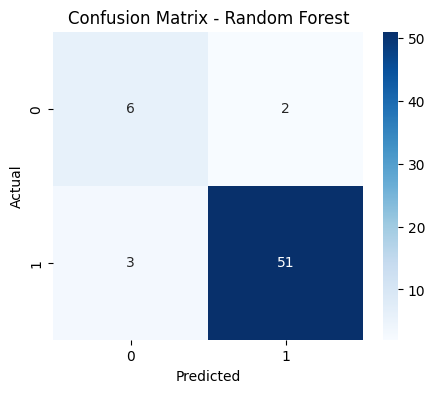

In [23]:
#evaluation
print("Accuracy:", f"{accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [24]:
#saving the model and scalar to the artifacts 
joblib.dump(best_model, "../artifacts/best_model.pkl")
joblib.dump(scaler, "../artifacts/scaler.pkl")
print("Saved best_model.pkl and scaler.pkl in artifacts/")

Saved best_model.pkl and scaler.pkl in artifacts/


In [35]:
#SHAP explainability
import shap
explain = shap.TreeExplainer(best_model)
x_test_scaled_df = pd.DataFrame(x_test_scaled, columns=x.columns)
shap_values = explain.shap_values(x_test_scaled_df)

In [39]:
if isinstance(shap_values, list):
    shap_values_to_use = shap_values[1]
else:
    shap_values_to_use = shap_values

print("SHAP values shape:", shap_values_to_use.shape)
print("x_test shape:", x_test_scaled_df.shape)
if shap_values_to_use.shape[1] == x_test_scaled_df.shape[1] + 1:
    shap_values_to_use = shap_values_to_use[:, :-1]

SHAP values shape: (62, 15, 2)
x_test shape: (62, 15)


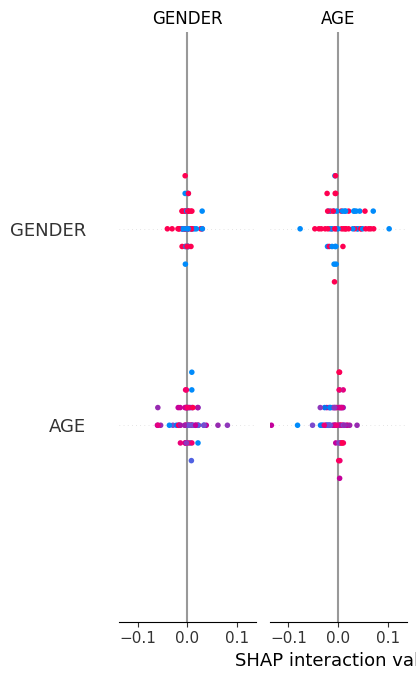

In [41]:
#summary plot
shap.summary_plot(shap_values_to_use, x_test_scaled_df, feature_names=x.columns)